# Experiment: arXiv Primary-Category Classifier Report Evidence

**Question.** How accurately can a title-and-abstract TF-IDF neural network predict the single `primary_category` of papers in the July 3-15, 2026 dataset?

**Success criteria.** Reproduce the saved strict test score from the dataset hash and seed, quantify class imbalance and cross-list ambiguity, export report-ready evidence, and generate one readable diagnostic figure.

In [1]:
from __future__ import annotations

import csv
import hashlib
import json
import sys
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from sklearn.metrics import f1_score
from sklearn.preprocessing import LabelEncoder

def find_repo(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").is_file() and (candidate / "dataset" / "papers.jsonl").is_file():
            return candidate
    raise FileNotFoundError("could not locate repository root from notebook working directory")

REPO = find_repo(Path.cwd())
sys.path.insert(0, str(REPO / "src"))

from arxiv_kg.category_classifier import (
    load_classifier,
    load_paper_examples,
    stratified_three_way_split,
)

SEED = 42
DATASET = REPO / "dataset" / "papers.jsonl"
METRICS_PATH = REPO / "data" / "category_classifier" / "metrics.json"
MODEL_DIR = REPO / "data" / "category_classifier"
OUTPUT_DIR = REPO / "classification" / "report"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Python {sys.version.split()[0]}; PyTorch {torch.__version__}")

Python 3.13.13; PyTorch 2.13.0


## Plan

1. Verify dataset provenance, row count, category threshold, duplicate IDs, and SHA-256.
2. Reconstruct the seed-42 train/validation/test split and replay the saved model.
3. Compare strict primary-category scoring with a post-hoc any-listed-category audit.
4. Export class counts, evidence JSON, and a diagnostic figure.

The post-hoc audit explains cross-listed papers; it does not replace the assignment's strict primary-label metric.

In [2]:
rows = [json.loads(line) for line in DATASET.read_text(encoding="utf-8").splitlines() if line]
metadata = json.loads((REPO / "dataset" / "metadata.json").read_text(encoding="utf-8"))
category_counts = Counter(row["primary_category"] for row in rows)
eligible_counts = {name: count for name, count in category_counts.items() if count >= 5}
excluded_counts = {name: count for name, count in category_counts.items() if count < 5}
dataset_sha256 = hashlib.sha256(DATASET.read_bytes()).hexdigest()
duplicate_ids = len(rows) - len({row["arxiv_id"] for row in rows})

dataset_evidence = {
    "source_records": metadata["source_paper_count"],
    "retained_records": len(rows),
    "date_start": min(row["submitted_date"] for row in rows),
    "date_end": max(row["submitted_date"] for row in rows),
    "raw_categories": len(category_counts),
    "eligible_categories": len(eligible_counts),
    "eligible_papers": sum(eligible_counts.values()),
    "excluded_rare_papers": sum(excluded_counts.values()),
    "duplicate_ids": duplicate_ids,
    "dataset_sha256": dataset_sha256,
}

assert dataset_evidence["retained_records"] == 7751
assert dataset_evidence["eligible_categories"] == 112
assert dataset_evidence["eligible_papers"] == 7708
assert duplicate_ids == 0
dataset_evidence

{'source_records': 11070,
 'retained_records': 7751,
 'date_start': '2026-07-03',
 'date_end': '2026-07-15',
 'raw_categories': 129,
 'eligible_categories': 112,
 'eligible_papers': 7708,
 'excluded_rare_papers': 43,
 'duplicate_ids': 0,
 'dataset_sha256': '1bfe64d02fffedaaa65ef00866e47e8c688966062ba54572c404a08c4657c78a'}

In [3]:
saved_report = json.loads(METRICS_PATH.read_text(encoding="utf-8"))
saved_metrics = saved_report["metrics"]
assert saved_report["configuration"]["dataset_sha256"] == dataset_sha256

examples, excluded = load_paper_examples(DATASET, minimum_class_count=5)
encoder = LabelEncoder()
targets = encoder.fit_transform([example.label for example in examples])
train_indices, validation_indices, test_indices = stratified_three_way_split(
    targets,
    validation_fraction=0.15,
    test_fraction=0.15,
    seed=SEED,
)

model, vectorizer, labels = load_classifier(MODEL_DIR)
assert np.array_equal(labels, encoder.classes_)
test_examples = [examples[index] for index in test_indices]
test_matrix = vectorizer.transform([example.text for example in test_examples])
test_features = torch.from_numpy(test_matrix.toarray().astype(np.float32, copy=False))

with torch.inference_mode():
    probabilities = torch.softmax(model(test_features), dim=1).numpy()

predictions = probabilities.argmax(axis=1)
test_targets = targets[test_indices]
strict_correct = predictions == test_targets
top_three = probabilities.argsort(axis=1)[:, -3:]
row_by_id = {row["arxiv_id"]: row for row in rows}

any_listed_top_one = []
any_listed_top_three = []
for index, example in enumerate(test_examples):
    listed = set(row_by_id[example.arxiv_id]["categories"])
    any_listed_top_one.append(str(labels[predictions[index]]) in listed)
    any_listed_top_three.append(
        any(str(labels[class_index]) in listed for class_index in top_three[index])
    )

correct_index = next(
    index for index, example in enumerate(test_examples)
    if example.arxiv_id == "2607.09583"
)
correct_example = {
    "arxiv_id": test_examples[correct_index].arxiv_id,
    "title": test_examples[correct_index].title,
    "true_category": str(labels[test_targets[correct_index]]),
    "predicted_category": str(labels[predictions[correct_index]]),
    "confidence": float(probabilities[correct_index, predictions[correct_index]]),
}

selected_error_ids = {"2607.07372", "2607.03072"}
selected_errors = []
for error in saved_report["high_confidence_mistakes"]:
    if error["arxiv_id"] in selected_error_ids:
        listed = row_by_id[error["arxiv_id"]]["categories"]
        selected_errors.append({**error, "listed_categories": listed})

strict_accuracy = float(strict_correct.mean())
strict_macro_f1 = float(
    f1_score(
        test_targets,
        predictions,
        labels=np.arange(len(labels)),
        average="macro",
        zero_division=0,
    )
)
strict_weighted_f1 = float(
    f1_score(
        test_targets,
        predictions,
        labels=np.arange(len(labels)),
        average="weighted",
        zero_division=0,
    )
)
strict_top_three_accuracy = float(
    np.any(top_three == test_targets[:, None], axis=1).mean()
)
per_category_f1 = f1_score(
    test_targets,
    predictions,
    labels=np.arange(len(labels)),
    average=None,
    zero_division=0,
)
confusion_counts = Counter(
    (str(labels[true_index]), str(labels[predicted_index]))
    for true_index, predicted_index in zip(test_targets, predictions)
    if true_index != predicted_index
)
recomputed_confusions = [
    {
        "true_category": pair[0],
        "predicted_category": pair[1],
        "papers": count,
    }
    for pair, count in sorted(
        confusion_counts.items(),
        key=lambda item: (-item[1], item[0][0], item[0][1]),
    )[:10]
]
recomputed_strict_metrics = {
    "accuracy": strict_accuracy,
    "macro_f1": strict_macro_f1,
    "weighted_f1": strict_weighted_f1,
    "top_3_accuracy": strict_top_three_accuracy,
    "correct_papers": int(strict_correct.sum()),
    "test_papers": len(test_targets),
}
strict_errors = int((~strict_correct).sum())
majority_class = int(np.bincount(targets[train_indices]).argmax())
majority_predictions = np.full_like(test_targets, majority_class)
majority_macro_f1 = float(
    f1_score(
        test_targets,
        majority_predictions,
        labels=np.arange(len(labels)),
        average="macro",
        zero_division=0,
    )
)
secondary_rescues = sum(
    (not bool(strict_correct[index])) and any_listed_top_one[index]
    for index in range(len(test_examples))
)
top_mistake_secondary_matches = sum(
    error["predicted_category"] in row_by_id[error["arxiv_id"]]["categories"]
    for error in saved_report["high_confidence_mistakes"]
)
test_supports = np.bincount(test_targets, minlength=len(labels))
zero_f1_categories = int((per_category_f1 == 0).sum())
evidence = {
    "dataset": dataset_evidence,
    "class_counts": dict(sorted(eligible_counts.items())),
    "excluded_class_counts": dict(sorted(excluded_counts.items())),
    "split": {
        "train": len(train_indices),
        "validation": len(validation_indices),
        "test": len(test_indices),
        "seed": SEED,
    },
    "configuration": saved_report["configuration"],
    "strict_primary_metrics": recomputed_strict_metrics,
    "saved_training_artifact_metrics": saved_metrics,
    "training_history_source": "saved metrics.json from the July 30 training run",
    "any_listed_top_one_accuracy": float(np.mean(any_listed_top_one)),
    "any_listed_top_three_accuracy": float(np.mean(any_listed_top_three)),
    "strict_errors": strict_errors,
    "strict_errors_matching_secondary_category": int(secondary_rescues),
    "majority_macro_f1": majority_macro_f1,
    "high_confidence_mistakes_screened": len(saved_report["high_confidence_mistakes"]),
    "high_confidence_mistakes_matching_secondary_category": int(top_mistake_secondary_matches),
    "median_test_support": float(np.median(test_supports)),
    "categories_with_four_or_fewer_test_papers": int((test_supports <= 4).sum()),
    "zero_f1_categories": int(zero_f1_categories),
    "correct_example": correct_example,
    "error_examples": selected_errors,
    "top_confusions": recomputed_confusions,
}

assert np.isclose(strict_accuracy, saved_metrics["accuracy"])
assert np.isclose(strict_macro_f1, saved_metrics["macro_f1"])
assert np.isclose(strict_weighted_f1, saved_metrics["weighted_f1"])
assert np.isclose(strict_top_three_accuracy, saved_metrics["top_3_accuracy"])
assert recomputed_confusions[:3] == saved_report["confusion_pairs"][:3]
assert int(strict_correct.sum()) == 710
assert secondary_rescues == 111
assert top_mistake_secondary_matches == 12
assert zero_f1_categories == 40
assert len(selected_errors) == 2

with (OUTPUT_DIR / "class_counts.csv").open("w", encoding="utf-8", newline="") as handle:
    writer = csv.writer(handle, lineterminator="\n")
    writer.writerow(["primary_category", "paper_count"])
    writer.writerows(sorted(eligible_counts.items()))

(OUTPUT_DIR / "report_evidence.json").write_text(
    json.dumps(evidence, indent=2, sort_keys=True) + "\n",
    encoding="utf-8",
)

{
    "strict_accuracy": strict_accuracy,
    "macro_f1": strict_macro_f1,
    "weighted_f1": strict_weighted_f1,
    "top_3_accuracy": strict_top_three_accuracy,
    "any_listed_top_one_accuracy": evidence["any_listed_top_one_accuracy"],
    "secondary_rescues": secondary_rescues,
    "majority_macro_f1": majority_macro_f1,
    "zero_f1_categories": zero_f1_categories,
}

{'strict_accuracy': 0.6136560069144339,
 'macro_f1': 0.3464990153000574,
 'weighted_f1': 0.5915351808466827,
 'top_3_accuracy': 0.8461538461538461,
 'any_listed_top_one_accuracy': 0.7095937770095073,
 'secondary_rescues': 111,
 'majority_macro_f1': 0.0016399416909620992,
 'zero_f1_categories': 40}

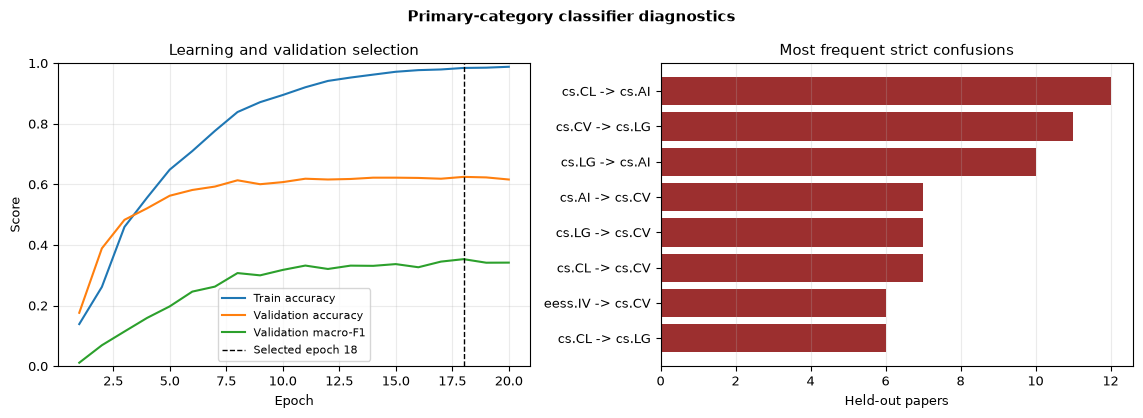

In [4]:
history = saved_report["history"]
epochs = [item["epoch"] for item in history]
confusions = saved_report["confusion_pairs"][:8]

plt.rcParams.update({"font.size": 9})
figure, (learning_axis, confusion_axis) = plt.subplots(1, 2, figsize=(11.5, 4.2))

learning_axis.plot(epochs, [item["train_accuracy"] for item in history], label="Train accuracy")
learning_axis.plot(epochs, [item["validation_accuracy"] for item in history], label="Validation accuracy")
learning_axis.plot(epochs, [item["validation_macro_f1"] for item in history], label="Validation macro-F1")
learning_axis.axvline(saved_metrics["best_epoch"], color="black", linestyle="--", linewidth=1, label="Selected epoch 18")
learning_axis.set(xlabel="Epoch", ylabel="Score", ylim=(0, 1), title="Learning and validation selection")
learning_axis.grid(alpha=0.25)
learning_axis.legend(fontsize=8)

pair_labels = [f"{item['true_category']} -> {item['predicted_category']}" for item in reversed(confusions)]
pair_counts = [item["papers"] for item in reversed(confusions)]
confusion_axis.barh(pair_labels, pair_counts, color="#9C2F2F")
confusion_axis.set(xlabel="Held-out papers", title="Most frequent strict confusions")
confusion_axis.grid(axis="x", alpha=0.25)

figure.suptitle("Primary-category classifier diagnostics", fontweight="bold")
figure.tight_layout()
figure.savefig(OUTPUT_DIR / "results_diagnostics.pdf", bbox_inches="tight")
figure.savefig(OUTPUT_DIR / "results_diagnostics.png", dpi=200, bbox_inches="tight")
plt.show()

## Results and next experiment

- Strict primary-category accuracy reproduced exactly: **710/1,157 = 61.37%**.
- Macro-F1 is **34.65%**, exposing weak performance in many small categories.
- Post-hoc any-listed-category top-1 accuracy is **70.96%**. Among 447 strict errors, 111 predictions match a valid secondary arXiv category.
- Epoch 18 was selected by validation macro-F1; the large train-validation gap indicates overfitting.

**Controlled next experiment.** Raise dropout from 0.25 to 0.50 while keeping the dataset, seed-42 split, TF-IDF features, optimizer, batch size, and epoch limit fixed. Prediction: validation macro-F1 will rise and the train-validation gap will narrow. Decide whether to retain the change from validation macro-F1 before reading its new test result.